In [70]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [2]:
data_df = pd.read_csv('../data/valid_comments.csv')
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6447646 entries, 0 to 6447645
Data columns (total 10 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   author                   object 
 1   post_id                  object 
 2   comment_id               object 
 3   post_title_sentiment     object 
 4   post_title_score         float64
 5   post_body_sentiment      object 
 6   post_body_score          float64
 7   comment_sentiment_type   object 
 8   comment_sentiment_value  float64
 9   comment_time             int64  
dtypes: float64(3), int64(1), object(6)
memory usage: 491.9+ MB


In [3]:
user_comments_on_neutral_posts_df = pd.read_csv('../data/user_comments_on_neutral_posts.csv')
user_comments_on_neutral_posts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22771 entries, 0 to 22770
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   user           22771 non-null  object
 1   comment_type   22771 non-null  object
 2   comment_value  22771 non-null  object
 3   comment_time   22771 non-null  object
dtypes: object(4)
memory usage: 711.7+ KB


In [4]:
values = []

for i in range(len(user_comments_on_neutral_posts_df)):
    user_id = user_comments_on_neutral_posts_df.iloc[i]['user']
    comment_types = user_comments_on_neutral_posts_df.iloc[i]['comment_type'].split(' ')
    comment_values = list(map(float, user_comments_on_neutral_posts_df.iloc[i]['comment_value'].split(' ')))

    user_emotion = []
    for comment_type, comment_value in zip(comment_types, comment_values):
        if comment_type == 'positive':
            user_emotion.append(comment_value)
        elif comment_type == 'negative':
            user_emotion.append(-comment_value)
        else:
            user_emotion.append(0)

    values.append(sum(user_emotion) / len(user_emotion))

user_comments_on_neutral_posts_df['user_emotion'] = values

In [5]:
user_comments_on_neutral_posts_df

,user,comment_type,comment_value,comment_time,user_emotion
0,------__------------,negative negative negative neutral neutral pos...,0.8 0.9 0.52 0.62 0.58 0.54 0.82 0.5 0.78 0.63...,1542547560 1543862201 1544293346 1544453248 15...,-0.276250
1,-----iMartijn-----,negative neutral neutral negative negative neg...,0.94 0.52 0.64 0.82 0.82 0.67 0.69 0.71 0.73 0...,1549058855 1557067751 1558016484 1563056420 15...,-0.391667
2,--sheogorath--,negative neutral neutral neutral negative neut...,0.66 0.65 0.55 0.5 0.73 0.49 0.8 0.53 0.67 0.7...,1552775184 1555289189 1555806088 1556241709 15...,-0.329524
3,-42069-,negative positive negative negative negative n...,0.57 0.86 0.89 0.58 0.53 0.75 0.79 0.98 0.78 0...,1579725839 1587489312 1587755085 1589027603 15...,-0.460625
4,-ACHTUNG-,negative neutral neutral negative neutral nega...,0.54 0.48 0.65 0.93 0.82 0.82 0.89 0.56 0.52,1582235202 1589049480 1599469405 1611659395 16...,-0.353333
...,...,...,...,...,...
22766,zwifter11,neutral negative negative negative negative ne...,0.72 0.85 0.58 0.8 0.57 0.75 0.87 0.88 0.67 0....,1578843902 1618095143 1618691339 1618766196 16...,-0.403095
22767,zxTheIronLungxz,negative positive neutral negative neutral neg...,0.57 0.9 0.5 0.87 0.41 0.91 0.55 0.5 0.6 0.86 ...,1580824240 1583417627 1587129661 1587901330 15...,-0.390714
22768,zxh01,negative positive negative negative negative n...,0.78 0.65 0.8 0.84 0.62 0.79 0.71,1576529484 1576529769 1576593016 1576593312 15...,-0.555714
22769,zztop610,neutral neutral neutral negative neutral negat...,0.91 0.73 0.55 0.89 0.84 0.7 0.74 0.87 0.8 0.9...,1625758737 1626798280 1631065393 1631627029 16...,-0.200400


In [6]:
# map user to user_emotion
user_list = user_comments_on_neutral_posts_df['user'].tolist()
user_emotion_list = user_comments_on_neutral_posts_df['user_emotion'].tolist()

user_emotion_dict = dict(zip(user_list, user_emotion_list))

In [115]:
len(user_emotion_list)

22771

In [118]:
user_comments_on_neutral_posts_df['comment_time'].str.split(' ').apply(len).value_counts()

comment_time
13     894
14     891
15     881
12     879
16     878
      ... 
314      1
503      1
346      1
270      1
495      1
Name: count, Length: 441, dtype: int64

In [121]:
len([x for x in user_emotion_list if x > 0]) / len(user_emotion_list)

0.03517632075885995

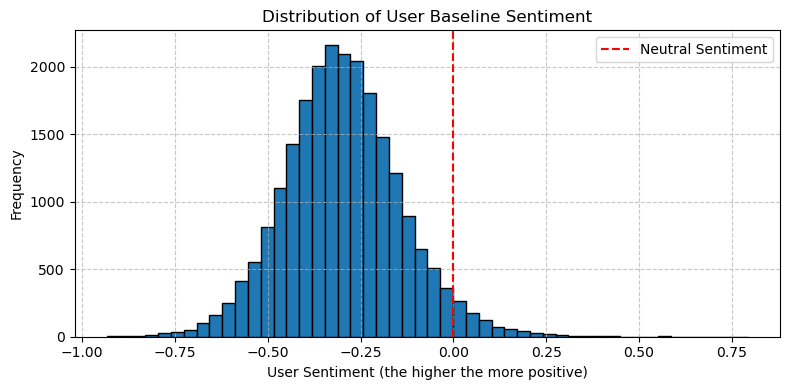

In [114]:
# draw the distribution of user_emotion_list
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))

plt.hist(user_emotion_list, bins=50, edgecolor='black', align='mid')
plt.xlabel('User Sentiment (the higher the more positive)')
plt.ylabel('Frequency')
plt.title('Distribution of User Baseline Sentiment')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', label='Neutral Sentiment')
plt.legend()
plt.savefig('../figures/user_emotion_distribution.png', dpi=300)
plt.show()


In [8]:
data_df.head()

,author,post_id,comment_id,post_title_sentiment,post_title_score,post_body_sentiment,post_body_score,comment_sentiment_type,comment_sentiment_value,comment_time
0,takatori,t3_1l707d,cbwcf4j,positive,0.69,positive,0.40,neutral,0.51,1377620739
1,Jaymez82,t3_1kzky0,cc1apv7,negative,0.86,negative,0.83,positive,0.54,1378262203
2,Jaymez82,t3_1la1oq,cc1asj5,negative,0.65,negative,0.41,negative,0.75,1378262423
3,apocolypticbosmer,t3_1lp37n,cc1hay4,negative,0.93,neutral,0.89,neutral,0.92,1378294246
4,Jaymez82,t3_1kv0lj,cc2jorr,positive,0.91,positive,0.40,positive,0.88,1378422860


In [9]:
regression_df = data_df[['post_id', 'comment_id', 'comment_sentiment_type', 'comment_sentiment_value', 'post_title_sentiment', 'post_title_score', 'post_body_sentiment', 'post_body_score', 'author', 'comment_time']]
regression_df.head()

,post_id,comment_id,comment_sentiment_type,comment_sentiment_value,post_title_sentiment,post_title_score,post_body_sentiment,post_body_score,author,comment_time
0,t3_1l707d,cbwcf4j,neutral,0.51,positive,0.69,positive,0.40,takatori,1377620739
1,t3_1kzky0,cc1apv7,positive,0.54,negative,0.86,negative,0.83,Jaymez82,1378262203
2,t3_1la1oq,cc1asj5,negative,0.75,negative,0.65,negative,0.41,Jaymez82,1378262423
3,t3_1lp37n,cc1hay4,neutral,0.92,negative,0.93,neutral,0.89,apocolypticbosmer,1378294246
4,t3_1kv0lj,cc2jorr,positive,0.88,positive,0.91,positive,0.40,Jaymez82,1378422860


In [10]:
# map the "postiv" to 1, "negative" to -1, "neutral" to 0
regression_df['post_title_sentiment'] = regression_df['post_title_sentiment'].map({'positive': 1, 'negative': -1, 'neutral': 0})
regression_df['post_body_sentiment'] = regression_df['post_body_sentiment'].map({'positive': 1, 'negative': -1, 'neutral': 0})
regression_df['comment_sentiment_type'] = regression_df['comment_sentiment_type'].map({'positive': 1, 'negative': -1, 'neutral': 0})
regression_df.head()

,post_id,comment_id,comment_sentiment_type,comment_sentiment_value,post_title_sentiment,post_title_score,post_body_sentiment,post_body_score,author,comment_time
0,t3_1l707d,cbwcf4j,0,0.51,1,0.69,1,0.40,takatori,1377620739
1,t3_1kzky0,cc1apv7,1,0.54,-1,0.86,-1,0.83,Jaymez82,1378262203
2,t3_1la1oq,cc1asj5,-1,0.75,-1,0.65,-1,0.41,Jaymez82,1378262423
3,t3_1lp37n,cc1hay4,0,0.92,-1,0.93,0,0.89,apocolypticbosmer,1378294246
4,t3_1kv0lj,cc2jorr,1,0.88,1,0.91,1,0.40,Jaymez82,1378422860


In [11]:
# create a new column, which is the product of comment_sentiment_type and comment_sentiment_value
regression_df['comment'] = regression_df['comment_sentiment_type'] * regression_df['comment_sentiment_value']
regression_df['post_title'] = regression_df['post_title_sentiment'] * regression_df['post_title_score']
regression_df['post_body'] = regression_df['post_body_sentiment'] * regression_df['post_body_score']
regression_df.head()



,post_id,comment_id,comment_sentiment_type,comment_sentiment_value,post_title_sentiment,post_title_score,post_body_sentiment,post_body_score,author,comment_time,comment,post_title,post_body
0,t3_1l707d,cbwcf4j,0,0.51,1,0.69,1,0.40,takatori,1377620739,0.00,0.69,0.40
1,t3_1kzky0,cc1apv7,1,0.54,-1,0.86,-1,0.83,Jaymez82,1378262203,0.54,-0.86,-0.83
2,t3_1la1oq,cc1asj5,-1,0.75,-1,0.65,-1,0.41,Jaymez82,1378262423,-0.75,-0.65,-0.41
3,t3_1lp37n,cc1hay4,0,0.92,-1,0.93,0,0.89,apocolypticbosmer,1378294246,0.00,-0.93,0.00
4,t3_1kv0lj,cc2jorr,1,0.88,1,0.91,1,0.40,Jaymez82,1378422860,0.88,0.91,0.40


In [12]:
# create a column user_emotion
regression_df['user_base_emotion'] = regression_df['author'].map(user_emotion_dict)
regression_df.head()


,post_id,comment_id,comment_sentiment_type,comment_sentiment_value,post_title_sentiment,post_title_score,post_body_sentiment,post_body_score,author,comment_time,comment,post_title,post_body,user_base_emotion
0,t3_1l707d,cbwcf4j,0,0.51,1,0.69,1,0.40,takatori,1377620739,0.00,0.69,0.40,-0.245333
1,t3_1kzky0,cc1apv7,1,0.54,-1,0.86,-1,0.83,Jaymez82,1378262203,0.54,-0.86,-0.83,-0.326667
2,t3_1la1oq,cc1asj5,-1,0.75,-1,0.65,-1,0.41,Jaymez82,1378262423,-0.75,-0.65,-0.41,-0.326667
3,t3_1lp37n,cc1hay4,0,0.92,-1,0.93,0,0.89,apocolypticbosmer,1378294246,0.00,-0.93,0.00,-0.446250
4,t3_1kv0lj,cc2jorr,1,0.88,1,0.91,1,0.40,Jaymez82,1378422860,0.88,0.91,0.40,-0.326667


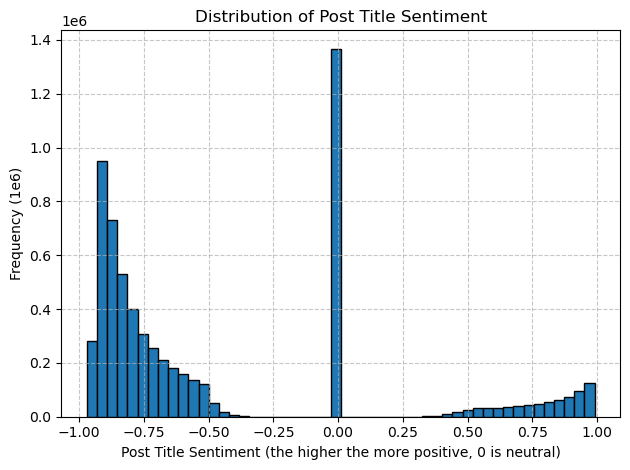

In [103]:
# histogram the regression_df['comment']

# histogram the regression_df['post_title']
plt.hist(regression_df['post_title'], bins=50, edgecolor='black', align='mid', density=False)
plt.xlabel('Post Title Sentiment (the higher the more positive, 0 is neutral)')
plt.ylabel('Frequency (1e6)')
plt.title('Distribution of Post Title Sentiment')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../figures/post_title_sentiment_distribution.png', dpi=300)
plt.show()

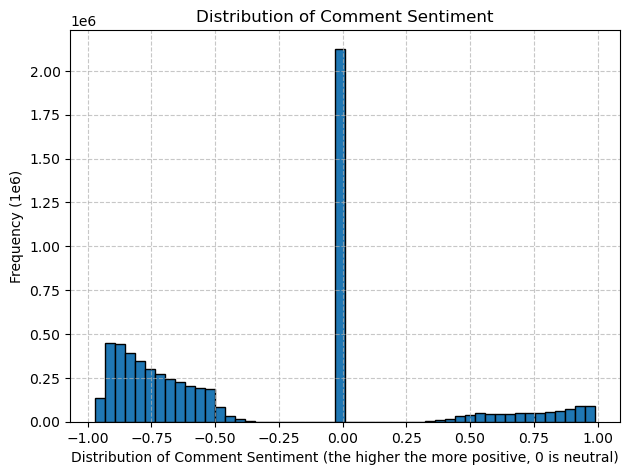

In [110]:
# histogram the regression_df['post_title']
plt.hist(regression_df['comment'], bins=50, edgecolor='black', align='mid', density=False)
plt.xlabel('Distribution of Comment Sentiment (the higher the more positive, 0 is neutral)')
plt.ylabel('Frequency (1e6)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.title('Distribution of Comment Sentiment')
plt.savefig('../figures/comment_sentiment_distribution.png', dpi=300)
plt.show()


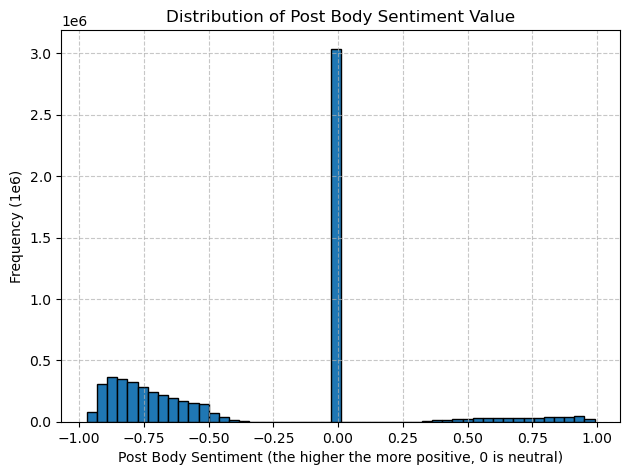

In [107]:
# histogram the regression_df['post_body']
plt.hist(regression_df['post_body'], bins=50, edgecolor='black', align='mid', density=False)
plt.xlabel('Post Body Sentiment (the higher the more positive, 0 is neutral)')
plt.ylabel('Frequency (1e6)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.title('Distribution of Post Body Sentiment Value')
plt.savefig('../figures/post_body_sentiment_distribution.png', dpi=300)
plt.show()




In [16]:
# conduct regression
# y is comment
# x is user_base_emotion, post_title, post_body
# add a constant term to the independent variables
y = regression_df['comment']
X = regression_df[['user_base_emotion', 'post_title', 'post_body']]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

In [17]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                comment   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                 8.222e+04
Date:                Thu, 05 Jun 2025   Prob (F-statistic):               0.00
Time:                        14:01:34   Log-Likelihood:            -5.0372e+06
No. Observations:             6447646   AIC:                         1.007e+07
Df Residuals:                 6447642   BIC:                         1.007e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0888      0.00

# Regression in user groups

In [18]:
regression_df.head()

,post_id,comment_id,comment_sentiment_type,comment_sentiment_value,post_title_sentiment,post_title_score,post_body_sentiment,post_body_score,author,comment_time,comment,post_title,post_body,user_base_emotion
0,t3_1l707d,cbwcf4j,0,0.51,1,0.69,1,0.40,takatori,1377620739,0.00,0.69,0.40,-0.245333
1,t3_1kzky0,cc1apv7,1,0.54,-1,0.86,-1,0.83,Jaymez82,1378262203,0.54,-0.86,-0.83,-0.326667
2,t3_1la1oq,cc1asj5,-1,0.75,-1,0.65,-1,0.41,Jaymez82,1378262423,-0.75,-0.65,-0.41,-0.326667
3,t3_1lp37n,cc1hay4,0,0.92,-1,0.93,0,0.89,apocolypticbosmer,1378294246,0.00,-0.93,0.00,-0.446250
4,t3_1kv0lj,cc2jorr,1,0.88,1,0.91,1,0.40,Jaymez82,1378422860,0.88,0.91,0.40,-0.326667


In [19]:
regression_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6447646 entries, 0 to 6447645
Data columns (total 14 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   post_id                  object 
 1   comment_id               object 
 2   comment_sentiment_type   int64  
 3   comment_sentiment_value  float64
 4   post_title_sentiment     int64  
 5   post_title_score         float64
 6   post_body_sentiment      int64  
 7   post_body_score          float64
 8   author                   object 
 9   comment_time             int64  
 10  comment                  float64
 11  post_title               float64
 12  post_body                float64
 13  user_base_emotion        float64
dtypes: float64(7), int64(4), object(3)
memory usage: 688.7+ MB


In [20]:
threshold = 0.005
len(regression_df[regression_df['user_base_emotion'] > threshold]), len(regression_df[regression_df['user_base_emotion'] < -threshold]), len(regression_df[regression_df['user_base_emotion'].abs() <= threshold])

(121056, 6305947, 20643)

In [21]:
user_groups = {
    'positive': regression_df[regression_df['user_base_emotion'] > threshold].reset_index(drop=True),
    'negative': regression_df[regression_df['user_base_emotion'] < -threshold].reset_index(drop=True),
    'neutral': regression_df[regression_df['user_base_emotion'].abs() <= threshold].reset_index(drop=True),
    'neutral-0.01': regression_df[regression_df['user_base_emotion'].abs() <= 0.01].reset_index(drop=True),
    'neutral-0.05': regression_df[regression_df['user_base_emotion'].abs() <= 0.05].reset_index(drop=True)
}
user_groups['positive'].head()


,post_id,comment_id,comment_sentiment_type,comment_sentiment_value,post_title_sentiment,post_title_score,post_body_sentiment,post_body_score,author,comment_time,comment,post_title,post_body,user_base_emotion
0,t3_1lvimq,cc5ak8h,0,0.51,0,0.62,-1,0.56,addjewelry,1378785958,0.00,0.00,-0.56,0.018571
1,t3_1rdxm5,cdmkx7x,-1,0.75,-1,0.77,-1,0.57,addjewelry,1385388878,-0.75,-0.77,-0.57,0.018571
2,t3_1rsvas,cdw3wp3,-1,0.50,-1,0.63,-1,0.81,addjewelry,1386455214,-0.50,-0.63,-0.81,0.018571
3,t3_1snlp9,cdzhczx,-1,0.71,-1,0.79,-1,0.86,addjewelry,1386799993,-0.71,-0.79,-0.86,0.018571
4,t3_1th7v3,ce8al8u,0,0.48,0,0.63,0,0.51,addjewelry,1387777185,0.00,0.00,0.00,0.018571


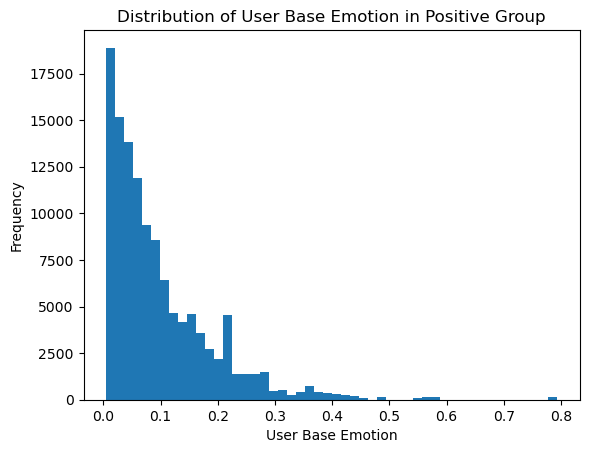

In [22]:
plt.hist(user_groups['positive']['user_base_emotion'], bins=50)
plt.title('Distribution of User Base Emotion in Positive Group')
plt.xlabel('User Base Emotion')
plt.ylabel('Frequency')
plt.show()


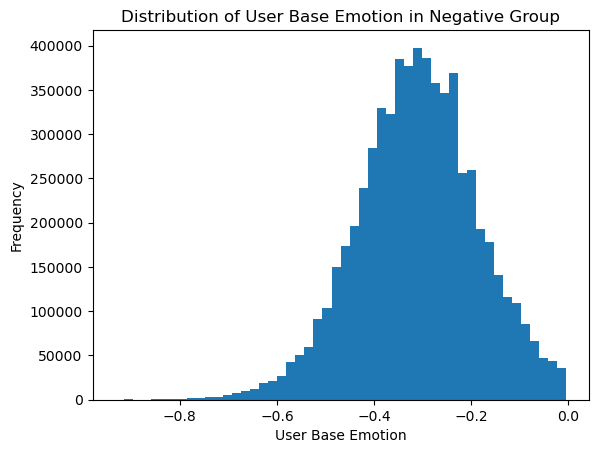

In [23]:
plt.hist(user_groups['negative']['user_base_emotion'], bins=50)
plt.title('Distribution of User Base Emotion in Negative Group')
plt.xlabel('User Base Emotion')
plt.ylabel('Frequency')
plt.show()



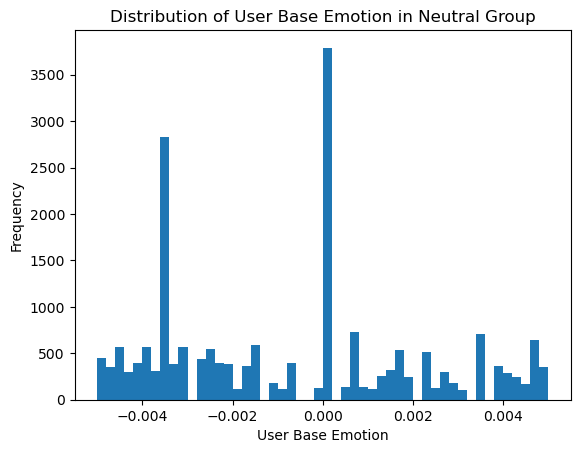

In [24]:
plt.hist(user_groups['neutral']['user_base_emotion'], bins=50)
plt.title('Distribution of User Base Emotion in Neutral Group')
plt.xlabel('User Base Emotion')
plt.ylabel('Frequency')
plt.show()



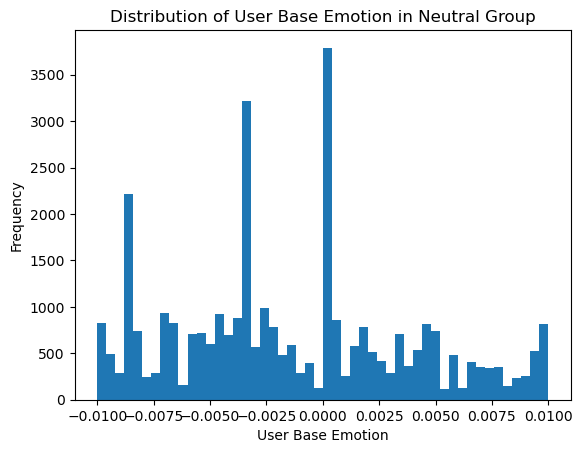

In [25]:
plt.hist(user_groups['neutral-0.01']['user_base_emotion'], bins=50)
plt.title('Distribution of User Base Emotion in Neutral Group')
plt.xlabel('User Base Emotion')
plt.ylabel('Frequency')
plt.show()


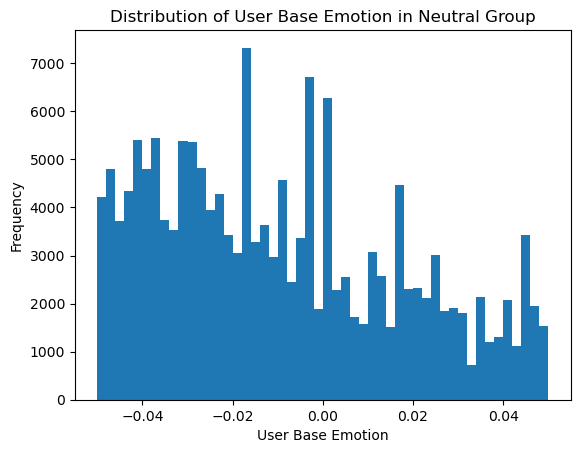

In [26]:
plt.hist(user_groups['neutral-0.05']['user_base_emotion'], bins=50)
plt.title('Distribution of User Base Emotion in Neutral Group')
plt.xlabel('User Base Emotion')
plt.ylabel('Frequency')
plt.show()


In [27]:
def regression(df):
    y = df['comment']
    X = df[['user_base_emotion', 'post_title', 'post_body']]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()
    print(model.summary())
    return model


In [141]:
# count the unique post_id, unique comment_id and unique author of each group
for group_name, group_df in user_groups.items():
    print(f"Group: {group_name}")
    print(f"Unique post_id: {group_df['post_id'].nunique()}")
    print(f"Unique comment_id: {group_df['comment_id'].nunique()}")
    print(f"Unique author: {group_df['author'].nunique()}")
    # print(len(group_df))
    print("\n")
    

Group: positive
Unique post_id: 88902
Unique comment_id: 121056
Unique author: 768


Group: negative
Unique post_id: 1073600
Unique comment_id: 6305947
Unique author: 21891


Group: neutral
Unique post_id: 19283
Unique comment_id: 20643
Unique author: 112


Group: neutral-0.01
Unique post_id: 30133
Unique comment_id: 33781
Unique author: 187


Group: neutral-0.05
Unique post_id: 117764
Unique comment_id: 163185
Unique author: 906




In [151]:
'positive', regression(user_groups['positive'])

                            OLS Regression Results                            
Dep. Variable:                comment   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     1783.
Date:                Thu, 05 Jun 2025   Prob (F-statistic):               0.00
Time:                        20:02:06   Log-Likelihood:            -1.0900e+05
No. Observations:              121056   AIC:                         2.180e+05
Df Residuals:                  121052   BIC:                         2.181e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0744      0.00

('positive',
 <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x35491b4a0>)

In [148]:
'neutral', regression(user_groups['neutral'])

                            OLS Regression Results                            
Dep. Variable:                comment   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     235.0
Date:                Thu, 05 Jun 2025   Prob (F-statistic):          6.38e-150
Time:                        19:59:34   Log-Likelihood:                -16289.
No. Observations:               20643   AIC:                         3.259e+04
Df Residuals:                   20639   BIC:                         3.262e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.1014      0.00

('neutral',
 <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x354555010>)

In [149]:
'negative', regression(user_groups['negative'])

                            OLS Regression Results                            
Dep. Variable:                comment   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                 7.511e+04
Date:                Thu, 05 Jun 2025   Prob (F-statistic):               0.00
Time:                        19:59:37   Log-Likelihood:            -4.9089e+06
No. Observations:             6305947   AIC:                         9.818e+06
Df Residuals:                 6305943   BIC:                         9.818e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0812      0.00

('negative',
 <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x354264380>)

In [150]:
# do not add user emotion in the neutral group
neutral_user_model = sm.OLS(user_groups['neutral']['comment'], sm.add_constant(user_groups['neutral'][['post_title', 'post_body']])).fit()
print('neutral', neutral_user_model.summary())

neutral                             OLS Regression Results                            
Dep. Variable:                comment   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     313.4
Date:                Thu, 05 Jun 2025   Prob (F-statistic):          8.09e-135
Time:                        20:01:11   Log-Likelihood:                -16327.
No. Observations:               20643   AIC:                         3.266e+04
Df Residuals:                   20640   BIC:                         3.268e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0934      0.005    -19.603 

In [32]:
regression(user_groups['neutral-0.01'])

                            OLS Regression Results                            
Dep. Variable:                comment   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     338.6
Date:                Thu, 05 Jun 2025   Prob (F-statistic):          1.13e-216
Time:                        14:01:59   Log-Likelihood:                -28099.
No. Observations:               33781   AIC:                         5.621e+04
Df Residuals:                   33777   BIC:                         5.624e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0971      0.00

In [33]:
regression(user_groups['neutral-0.05'])

                            OLS Regression Results                            
Dep. Variable:                comment   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     1661.
Date:                Thu, 05 Jun 2025   Prob (F-statistic):               0.00
Time:                        14:02:01   Log-Likelihood:            -1.4100e+05
No. Observations:              163185   AIC:                         2.820e+05
Df Residuals:                  163181   BIC:                         2.821e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0816      0.00

# Time interval analysis

In [34]:
interval_regression_df = regression_df.copy()
interval_regression_df

,post_id,comment_id,comment_sentiment_type,comment_sentiment_value,post_title_sentiment,post_title_score,post_body_sentiment,post_body_score,author,comment_time,comment,post_title,post_body,user_base_emotion
0,t3_1l707d,cbwcf4j,0,0.51,1,0.69,1,0.40,takatori,1377620739,0.00,0.69,0.40,-0.245333
1,t3_1kzky0,cc1apv7,1,0.54,-1,0.86,-1,0.83,Jaymez82,1378262203,0.54,-0.86,-0.83,-0.326667
2,t3_1la1oq,cc1asj5,-1,0.75,-1,0.65,-1,0.41,Jaymez82,1378262423,-0.75,-0.65,-0.41,-0.326667
3,t3_1lp37n,cc1hay4,0,0.92,-1,0.93,0,0.89,apocolypticbosmer,1378294246,0.00,-0.93,0.00,-0.446250
4,t3_1kv0lj,cc2jorr,1,0.88,1,0.91,1,0.40,Jaymez82,1378422860,0.88,0.91,0.40,-0.326667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6447641,t3_1hqqqce,m4rvk4a,1,0.54,-1,0.88,-1,0.72,throwaway669_663,1735689496,0.54,-0.88,-0.72,-0.244444
6447642,t3_1hqr60k,m4rvktv,-1,0.66,-1,0.69,-1,0.89,MercifulOtter,1735689504,-0.66,-0.69,-0.89,-0.380357
6447643,t3_1hqr60k,m4rvnsn,0,0.60,-1,0.69,-1,0.89,scugmoment,1735689535,0.00,-0.69,-0.89,0.046250
6447644,t3_1hqr0ih,m4rvrm1,-1,0.56,0,0.90,-1,0.81,noronto,1735689575,-0.56,0.00,-0.81,-0.387818


In [35]:
# utc time to date
interval_regression_df['date'] = pd.to_datetime(data_df['comment_time'], unit='s')
interval_regression_df.head()


,post_id,comment_id,comment_sentiment_type,comment_sentiment_value,post_title_sentiment,post_title_score,post_body_sentiment,post_body_score,author,comment_time,comment,post_title,post_body,user_base_emotion,date
0,t3_1l707d,cbwcf4j,0,0.51,1,0.69,1,0.40,takatori,1377620739,0.00,0.69,0.40,-0.245333,2013-08-27 16:25:39
1,t3_1kzky0,cc1apv7,1,0.54,-1,0.86,-1,0.83,Jaymez82,1378262203,0.54,-0.86,-0.83,-0.326667,2013-09-04 02:36:43
2,t3_1la1oq,cc1asj5,-1,0.75,-1,0.65,-1,0.41,Jaymez82,1378262423,-0.75,-0.65,-0.41,-0.326667,2013-09-04 02:40:23
3,t3_1lp37n,cc1hay4,0,0.92,-1,0.93,0,0.89,apocolypticbosmer,1378294246,0.00,-0.93,0.00,-0.446250,2013-09-04 11:30:46
4,t3_1kv0lj,cc2jorr,1,0.88,1,0.91,1,0.40,Jaymez82,1378422860,0.88,0.91,0.40,-0.326667,2013-09-05 23:14:20


In [36]:
# min and max date
interval_regression_df['date'].min(), interval_regression_df['date'].max()

(Timestamp('2013-08-27 16:25:39'), Timestamp('2024-12-31 23:59:43'))

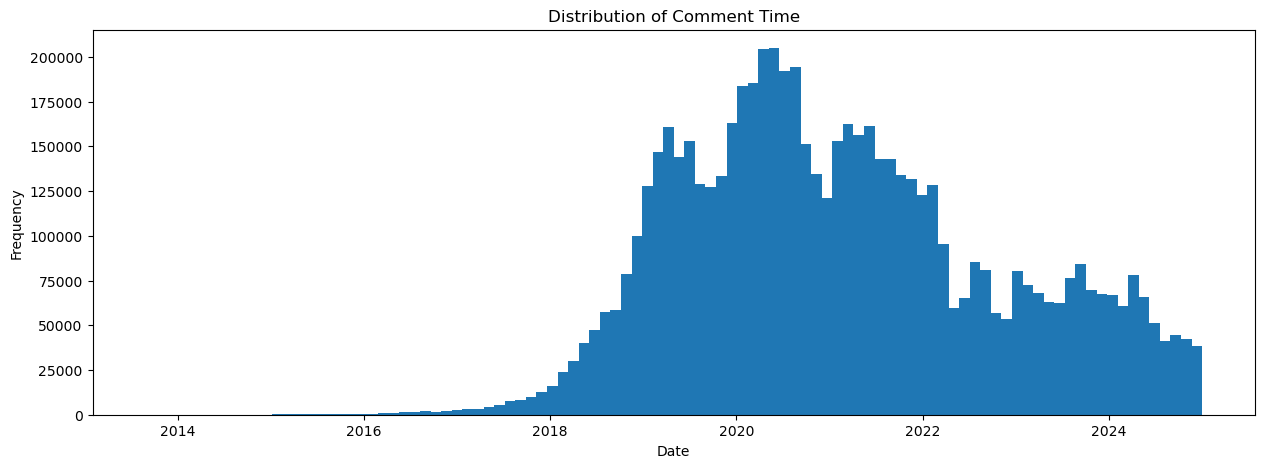

In [37]:
# draw the distribution of the date
plt.figure(figsize=(15, 5))
plt.hist(interval_regression_df['date'], bins=100)
plt.title('Distribution of Comment Time')
plt.xlabel('Date')
plt.ylabel('Frequency')

plt.show()


In [38]:
bin_cnt = 5

In [39]:
interval_regression_df['date_interval'] = pd.cut(interval_regression_df['date'], bins=bin_cnt, labels=[str(i) for i in range(bin_cnt)])

In [40]:
interval_regression_df['date_interval'].value_counts().sort_index()

date_interval
0       3833
1     108564
2    2476289
3    2615370
4    1243590
Name: count, dtype: int64

In [50]:
import numpy as np
spaces = np.linspace(interval_regression_df['comment_time'].min(), interval_regression_df['comment_time'].max(), bin_cnt + 1)
spaces

array([1.37762074e+09, 1.44923451e+09, 1.52084828e+09, 1.59246205e+09,
       1.66407581e+09, 1.73568958e+09])

In [51]:
# input the timesteamp, output the interval
def get_interval(timestamp):
    return np.digitize(timestamp, spaces) - 1

In [52]:
interval_regression_df['comment_time'].apply(get_interval).value_counts().sort_index()

comment_time
0       3833
1     108564
2    2476289
3    2615370
4    1243589
5          1
Name: count, dtype: int64

In [53]:
interval_regression_df['comment_time'].min(), interval_regression_df['comment_time'].max()

(1377620739, 1735689583)

In [54]:
# print the min and max date of each interval
for i in range(5):
    print(interval_regression_df[interval_regression_df['date_interval'] == str(i)]['date'].min(), interval_regression_df[interval_regression_df['date_interval'] == str(i)]['date'].max())

2013-08-27 16:25:39 2015-12-04 12:58:42
2015-12-04 13:47:04 2018-03-12 09:41:27
2018-03-12 09:55:02 2020-06-18 06:33:59
2020-06-18 06:34:23 2022-09-25 03:16:50
2022-09-25 03:16:55 2024-12-31 23:59:43


In [55]:
user_comments_on_neutral_posts_df

,user,comment_type,comment_value,comment_time,user_emotion
0,------__------------,negative negative negative neutral neutral pos...,0.8 0.9 0.52 0.62 0.58 0.54 0.82 0.5 0.78 0.63...,1542547560 1543862201 1544293346 1544453248 15...,-0.276250
1,-----iMartijn-----,negative neutral neutral negative negative neg...,0.94 0.52 0.64 0.82 0.82 0.67 0.69 0.71 0.73 0...,1549058855 1557067751 1558016484 1563056420 15...,-0.391667
2,--sheogorath--,negative neutral neutral neutral negative neut...,0.66 0.65 0.55 0.5 0.73 0.49 0.8 0.53 0.67 0.7...,1552775184 1555289189 1555806088 1556241709 15...,-0.329524
3,-42069-,negative positive negative negative negative n...,0.57 0.86 0.89 0.58 0.53 0.75 0.79 0.98 0.78 0...,1579725839 1587489312 1587755085 1589027603 15...,-0.460625
4,-ACHTUNG-,negative neutral neutral negative neutral nega...,0.54 0.48 0.65 0.93 0.82 0.82 0.89 0.56 0.52,1582235202 1589049480 1599469405 1611659395 16...,-0.353333
...,...,...,...,...,...
22766,zwifter11,neutral negative negative negative negative ne...,0.72 0.85 0.58 0.8 0.57 0.75 0.87 0.88 0.67 0....,1578843902 1618095143 1618691339 1618766196 16...,-0.403095
22767,zxTheIronLungxz,negative positive neutral negative neutral neg...,0.57 0.9 0.5 0.87 0.41 0.91 0.55 0.5 0.6 0.86 ...,1580824240 1583417627 1587129661 1587901330 15...,-0.390714
22768,zxh01,negative positive negative negative negative n...,0.78 0.65 0.8 0.84 0.62 0.79 0.71,1576529484 1576529769 1576593016 1576593312 15...,-0.555714
22769,zztop610,neutral neutral neutral negative neutral negat...,0.91 0.73 0.55 0.89 0.84 0.7 0.74 0.87 0.8 0.9...,1625758737 1626798280 1631065393 1631627029 16...,-0.200400


In [56]:
get_interval('1543862201'), get_interval(1543862201)

(2, 2)

In [57]:
# iterate through the user_comments_on_neutral_posts_df
from tqdm import trange


user_comment_time_interval = []
for i in trange(len(user_comments_on_neutral_posts_df)):
    user = user_comments_on_neutral_posts_df.iloc[i]['user']
    comment_value = user_comments_on_neutral_posts_df.iloc[i]['comment_value']
    comment_time = user_comments_on_neutral_posts_df.iloc[i]['comment_time']
    comment_type = user_comments_on_neutral_posts_df.iloc[i]['comment_type']

    mini_df = pd.DataFrame({
        'comment_value': comment_value.split(' '),
        'comment_time': comment_time.split(' '),
        'comment_type': comment_type.split(' '),
    })
    mini_df['comment_time'] = mini_df['comment_time'].astype(int)
    mini_df['comment_value'] = mini_df['comment_value'].astype(float)

    mini_df['mapped_comment_type'] = mini_df['comment_type'].map({'positive': 1, 'negative': -1, 'neutral': 0})
    mini_df['comment_value'] = mini_df['comment_value'] * mini_df['mapped_comment_type']

    mini_df['time_bin'] = mini_df['comment_time'].apply(get_interval)

    bin_threshold = 10
    valid_bins = [k for k, v in mini_df['time_bin'].value_counts().items() if v > bin_threshold]
    mini_df = mini_df[mini_df['time_bin'].isin(valid_bins)]
    mini_df['comment_value'] = mini_df['comment_value'].astype(float)
    # get the average of the comment_value in each time bin
    result = [{'user': user, 'time_bin': k, 'comment_value': v} for k, v in mini_df.groupby('time_bin')['comment_value'].mean().items()]
    user_comment_time_interval.extend(result)

user_comment_time_interval_df = pd.DataFrame(user_comment_time_interval)
user_comment_time_interval_df.head()


100%|██████████| 22771/22771 [00:20<00:00, 1120.62it/s]


,user,time_bin,comment_value
0,------__------------,2,-0.285161
1,--sheogorath--,2,-0.313889
2,-42069-,3,-0.514545
3,-Ab3-,3,-0.199500
4,-ArchitectOfThought-,2,-0.438929


In [131]:
user_comment_time_interval_df['time_bin'].value_counts().sort_index()

time_bin
0       8
1     204
2    6742
3    9628
4    3472
Name: count, dtype: int64

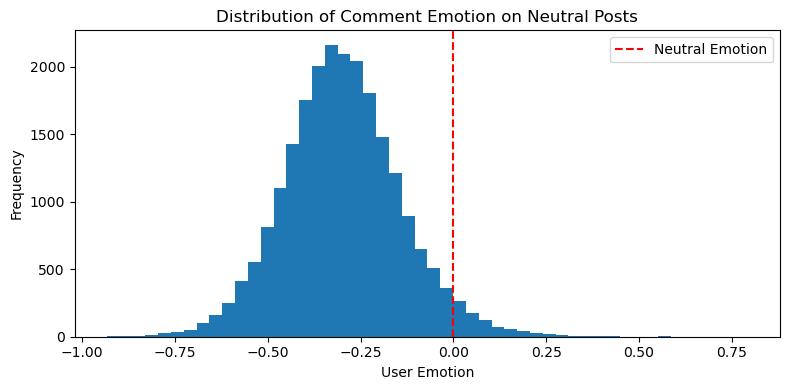

In [59]:
# draw the distribution of user_emotion_list
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.axvline(x=0, color='red', linestyle='--', label='Neutral Emotion')
plt.legend()
plt.hist(user_comments_on_neutral_posts_df['user_emotion'].tolist(), bins=50)
plt.xlabel('User Emotion')
plt.ylabel('Frequency')
plt.title('Distribution of Comment Emotion on Neutral Posts')
plt.tight_layout()
# plt.savefig('../figures/user_emotion_distribution.png', dpi=300)
plt.show()


Time Bin 0: -0.3393164335664336, len: 8


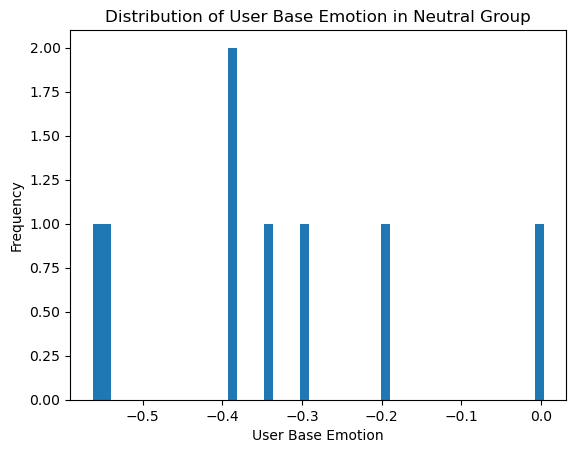

Time Bin 1: -0.34341676659622195, len: 204


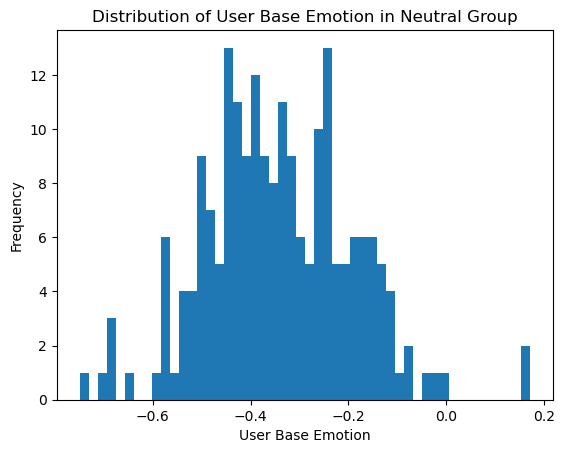

Time Bin 2: -0.31651016487526307, len: 6742


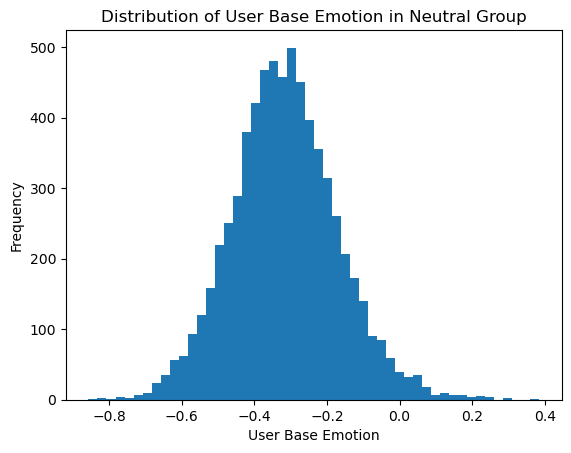

Time Bin 3: -0.29654117891609333, len: 9628


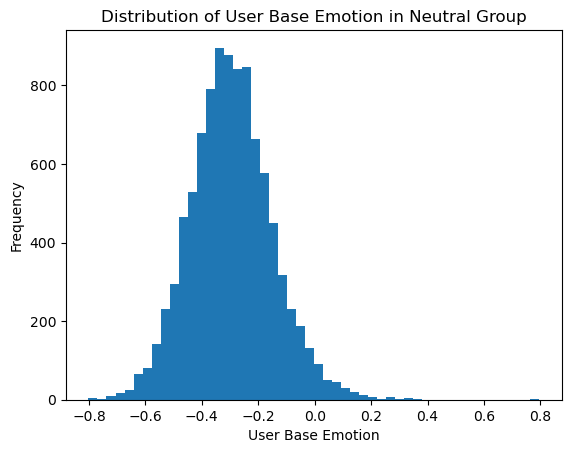

Time Bin 4: -0.2865245446793198, len: 3472


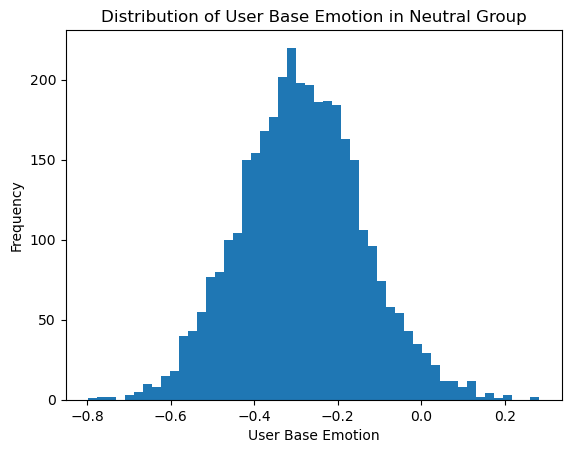

In [60]:
for i in range(5):
    print(f"Time Bin {i}: {user_comment_time_interval_df[user_comment_time_interval_df['time_bin'] == i]['comment_value'].mean()}, len: {len(user_comment_time_interval_df[user_comment_time_interval_df['time_bin'] == i])}")
    plt.hist(user_comment_time_interval_df[user_comment_time_interval_df['time_bin'] == i]['comment_value'].tolist(), bins=50)
    plt.title('Distribution of User Base Emotion in Neutral Group')
    plt.xlabel('User Base Emotion')
    plt.ylabel('Frequency')
    plt.show()


In [137]:
for i in range(bin_cnt):
    valid_commentator = user_comment_time_interval_df[user_comment_time_interval_df['time_bin'] == i]['user'].unique()
    local_df = interval_regression_df[interval_regression_df['date_interval'] == str(i)].reset_index(drop=True)
    local_df = local_df[local_df['author'].isin(valid_commentator)].reset_index(drop=True)
    print(f"unique posts: {local_df['post_id'].nunique()}, bin {i}")

unique posts: 1099, bin 0
unique posts: 26229, bin 1
unique posts: 520035, bin 2
unique posts: 393879, bin 3
unique posts: 116225, bin 4


In [61]:
models = []
for i in range(bin_cnt):
    valid_commentator = user_comment_time_interval_df[user_comment_time_interval_df['time_bin'] == i]['user'].unique()
    local_df = interval_regression_df[interval_regression_df['date_interval'] == str(i)].reset_index(drop=True)
    local_df = local_df[local_df['author'].isin(valid_commentator)].reset_index(drop=True)
    local_user_emotion_dict = user_comment_time_interval_df[user_comment_time_interval_df['time_bin'] == i].set_index('user')['comment_value'].to_dict()
    local_df['user_base_emotion'] = local_df['author'].map(local_user_emotion_dict)
    print(f'time bin {i}')
    models.append(regression(local_df))


time bin 0
                            OLS Regression Results                            
Dep. Variable:                comment   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     5.940
Date:                Thu, 05 Jun 2025   Prob (F-statistic):           0.000501
Time:                        14:04:29   Log-Likelihood:                -1056.9
No. Observations:                1575   AIC:                             2122.
Df Residuals:                    1571   BIC:                             2143.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.318

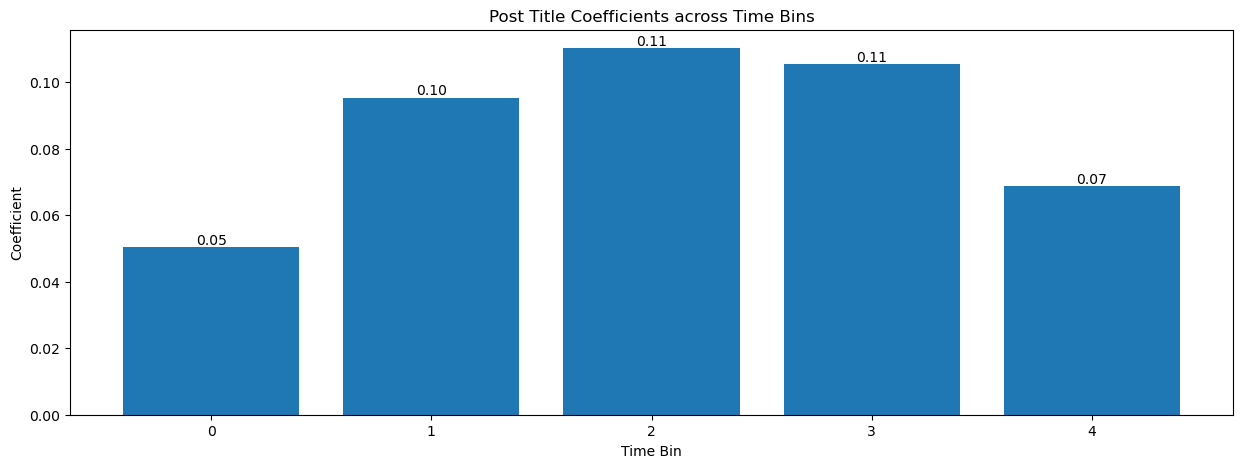

In [62]:
# get the coeff of post_title and post_body and do bar plot across the time bins
title_coeffs = [models[i].params['post_title'] for i in range(bin_cnt)]
body_coeffs = [models[i].params['post_body'] for i in range(bin_cnt)]
user_base_emotion_coeffs = [models[i].params['user_base_emotion'] for i in range(bin_cnt)]

plt.figure(figsize=(15, 5))
plt.bar(range(bin_cnt), title_coeffs)
plt.title('Post Title Coefficients across Time Bins')
plt.xlabel('Time Bin')
plt.ylabel('Coefficient')
# show value on the bar
for i in range(bin_cnt):
    plt.text(i, title_coeffs[i], f'{title_coeffs[i]:.2f}', ha='center', va='bottom')
plt.show()



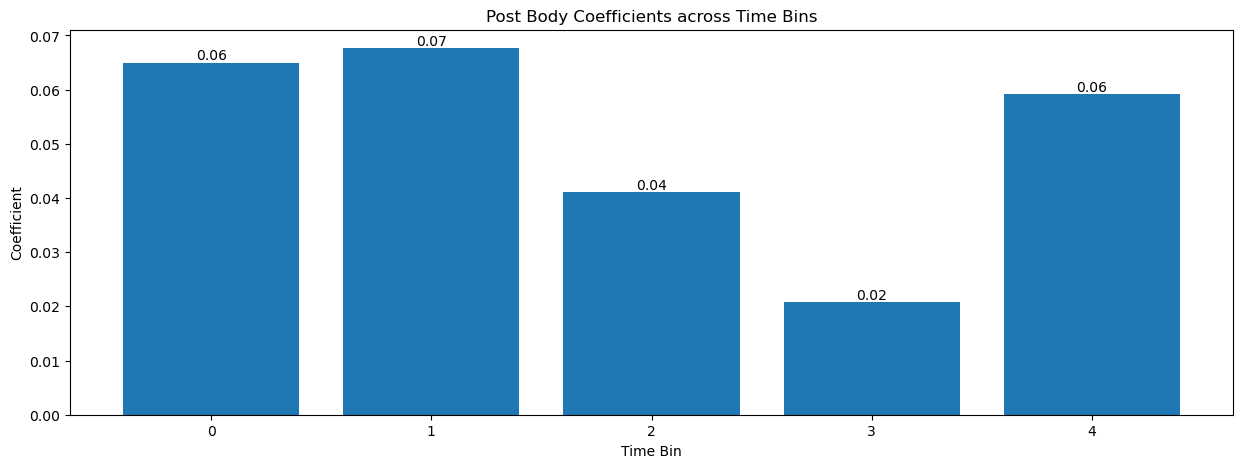

In [63]:
plt.figure(figsize=(15, 5))
plt.bar(range(bin_cnt), body_coeffs)
plt.title('Post Body Coefficients across Time Bins')
plt.xlabel('Time Bin')
plt.ylabel('Coefficient')
# show value on the bar
for i in range(bin_cnt):
    plt.text(i, body_coeffs[i], f'{body_coeffs[i]:.2f}', ha='center', va='bottom')
plt.show()


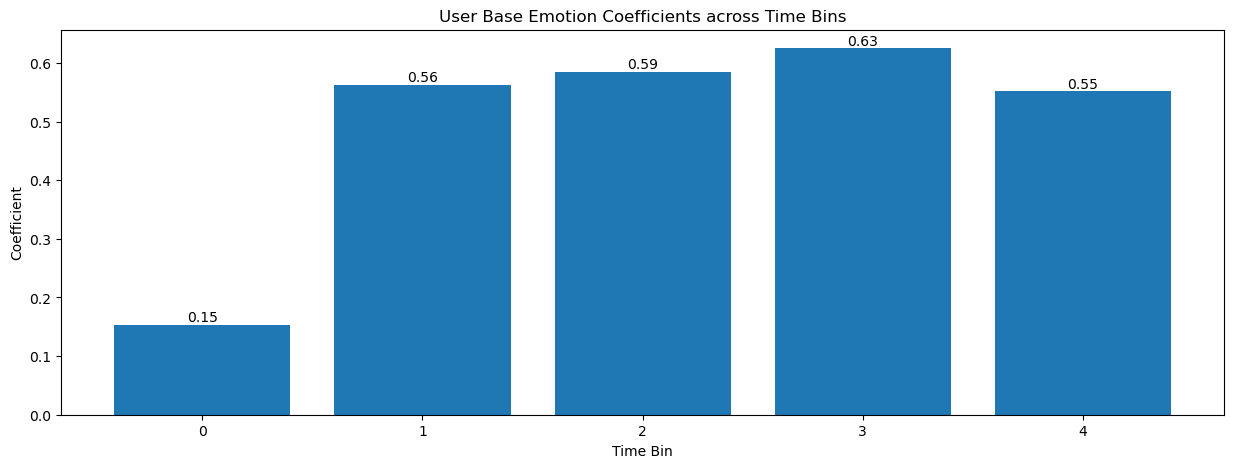

In [64]:
plt.figure(figsize=(15, 5))
plt.bar(range(bin_cnt), user_base_emotion_coeffs)
plt.title('User Base Emotion Coefficients across Time Bins')
plt.xlabel('Time Bin')
plt.ylabel('Coefficient')
# show value under the bar
for i in range(bin_cnt):
    plt.text(i, user_base_emotion_coeffs[i], f'{user_base_emotion_coeffs[i]:.2f}', ha='center', va='bottom')
plt.show()


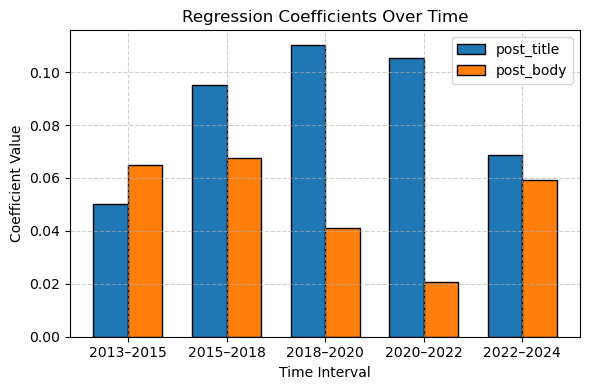

In [129]:
import matplotlib.pyplot as plt
import numpy as np

# Time bins as labels
time_labels = [
    '2013–2015',
    '2015–2018',
    '2018–2020',
    '2020–2022',
    '2022–2024'
]

# Corresponding coefficients
post_title_coef = [0.0503, 0.0953, 0.1103, 0.1054, 0.0688]
post_body_coef = [0.0650, 0.0677, 0.0410, 0.0207, 0.0592]

# Bar width and positions
x = np.arange(len(time_labels))
bar_width = 0.35

# Plotting
plt.figure(figsize=(6, 4))
plt.bar(x - bar_width / 2, post_title_coef, width=bar_width, label='post_title', edgecolor='black', )
plt.bar(x + bar_width / 2, post_body_coef, width=bar_width, label='post_body', edgecolor='black', )

# Labels and title
plt.xlabel('Time Interval')
plt.ylabel('Coefficient Value')
plt.title('Regression Coefficients Over Time')
plt.xticks(x, time_labels)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save or show
plt.savefig('../figures/post_features_over_time.png', dpi=300)
plt.show()

# Year distribution

In [156]:
interval_regression_df['year'] = interval_regression_df['date'].astype(str).str[:4].astype(int)

In [157]:
interval_regression_df

,post_id,comment_id,comment_sentiment_type,comment_sentiment_value,post_title_sentiment,post_title_score,post_body_sentiment,post_body_score,author,comment_time,comment,post_title,post_body,user_base_emotion,date,date_interval,year
0,t3_1l707d,cbwcf4j,0,0.51,1,0.69,1,0.40,takatori,1377620739,0.00,0.69,0.40,-0.245333,2013-08-27 16:25:39,0,2013
1,t3_1kzky0,cc1apv7,1,0.54,-1,0.86,-1,0.83,Jaymez82,1378262203,0.54,-0.86,-0.83,-0.326667,2013-09-04 02:36:43,0,2013
2,t3_1la1oq,cc1asj5,-1,0.75,-1,0.65,-1,0.41,Jaymez82,1378262423,-0.75,-0.65,-0.41,-0.326667,2013-09-04 02:40:23,0,2013
3,t3_1lp37n,cc1hay4,0,0.92,-1,0.93,0,0.89,apocolypticbosmer,1378294246,0.00,-0.93,0.00,-0.446250,2013-09-04 11:30:46,0,2013
4,t3_1kv0lj,cc2jorr,1,0.88,1,0.91,1,0.40,Jaymez82,1378422860,0.88,0.91,0.40,-0.326667,2013-09-05 23:14:20,0,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6447641,t3_1hqqqce,m4rvk4a,1,0.54,-1,0.88,-1,0.72,throwaway669_663,1735689496,0.54,-0.88,-0.72,-0.244444,2024-12-31 23:58:16,4,2024
6447642,t3_1hqr60k,m4rvktv,-1,0.66,-1,0.69,-1,0.89,MercifulOtter,1735689504,-0.66,-0.69,-0.89,-0.380357,2024-12-31 23:58:24,4,2024
6447643,t3_1hqr60k,m4rvnsn,0,0.60,-1,0.69,-1,0.89,scugmoment,1735689535,0.00,-0.69,-0.89,0.046250,2024-12-31 23:58:55,4,2024
6447644,t3_1hqr0ih,m4rvrm1,-1,0.56,0,0.90,-1,0.81,noronto,1735689575,-0.56,0.00,-0.81,-0.387818,2024-12-31 23:59:35,4,2024


In [205]:
# deduplicate the post_id in interval_regression_df
unique_posts_df = interval_regression_df.drop_duplicates(subset=['post_id']).reset_index(drop=True)

In [206]:
len(unique_posts_df), len(interval_regression_df['post_id'].unique())

(1077617, 1077617)

In [188]:
# bar plot the comment_sentiment_type across years
comment_sentiment_counts = interval_regression_df.groupby('year')['comment_sentiment_type'].value_counts().unstack()
comment_sentiment_counts

comment_sentiment_type,-1,0,1
year,,,
2013,58,25,12
2014,309,151,41
2015,2268,1079,325
2016,7482,3347,1170
2017,36515,17039,6561
2018,266757,142642,51793
2019,722550,398329,137123
2020,847052,512376,195411
2021,687941,429062,165663


In [190]:
comment_sentiment_counts.columns = comment_sentiment_counts.columns.map({1: 'positive', -1 : 'negative', 0 : 'neutral'})
comment_sentiment_counts

comment_sentiment_type,negative,neutral,positive
year,,,
2013,58,25,12
2014,309,151,41
2015,2268,1079,325
2016,7482,3347,1170
2017,36515,17039,6561
2018,266757,142642,51793
2019,722550,398329,137123
2020,847052,512376,195411
2021,687941,429062,165663


In [191]:
comment_sentiment_counts['sum'] = comment_sentiment_counts.sum(axis=1)
comment_sentiment_counts['positive_ratio'] = comment_sentiment_counts['positive'] / comment_sentiment_counts['sum']
comment_sentiment_counts['negative_ratio'] = comment_sentiment_counts['negative'] / comment_sentiment_counts['sum']
comment_sentiment_counts['neutral_ratio'] = comment_sentiment_counts['neutral'] / comment_sentiment_counts['sum']
comment_sentiment_counts

comment_sentiment_type,negative,neutral,positive,sum,positive_ratio,negative_ratio,neutral_ratio
year,,,,,,,
2013,58,25,12,95,0.126316,0.610526,0.263158
2014,309,151,41,501,0.081836,0.616766,0.301397
2015,2268,1079,325,3672,0.088508,0.617647,0.293845
2016,7482,3347,1170,11999,0.097508,0.623552,0.278940
2017,36515,17039,6561,60115,0.109141,0.607419,0.283440
2018,266757,142642,51793,461192,0.112302,0.578408,0.309290
2019,722550,398329,137123,1258002,0.109001,0.574363,0.316636
2020,847052,512376,195411,1554839,0.125679,0.544784,0.329536
2021,687941,429062,165663,1282666,0.129155,0.536337,0.334508


In [207]:
post_title_sentiment_counts = unique_posts_df.groupby('year')['post_title_sentiment'].value_counts().unstack()
post_title_sentiment_counts.columns = post_title_sentiment_counts.columns.map({1: 'positive', -1 : 'negative', 0 : 'neutral'})
post_title_sentiment_counts['sum'] = post_title_sentiment_counts.sum(axis=1)
post_title_sentiment_counts['positive_ratio'] = post_title_sentiment_counts['positive'] / post_title_sentiment_counts['sum']
post_title_sentiment_counts['negative_ratio'] = post_title_sentiment_counts['negative'] / post_title_sentiment_counts['sum']
post_title_sentiment_counts['neutral_ratio'] = post_title_sentiment_counts['neutral'] / post_title_sentiment_counts['sum']
post_title_sentiment_counts

post_title_sentiment,negative,neutral,positive,sum,positive_ratio,negative_ratio,neutral_ratio
year,,,,,,,
2013,45,14,15,74,0.202703,0.608108,0.189189
2014,254,52,39,345,0.113043,0.736232,0.150725
2015,1117,265,141,1523,0.092580,0.733421,0.173999
2016,2856,768,397,4021,0.098732,0.710271,0.190997
2017,11217,2757,1750,15724,0.111295,0.713368,0.175337
2018,79055,21151,13390,113596,0.117874,0.695931,0.186195
2019,184686,52933,33816,271435,0.124582,0.680406,0.195012
2020,187503,58667,43366,289536,0.149778,0.647598,0.202624
2021,117255,51656,27471,196382,0.139886,0.597076,0.263038


In [208]:
post_body_sentiment_counts = unique_posts_df.groupby('year')['post_body_sentiment'].value_counts().unstack()
post_body_sentiment_counts.columns = post_body_sentiment_counts.columns.map({1: 'positive', -1 : 'negative', 0 : 'neutral'})
post_body_sentiment_counts['sum'] = post_body_sentiment_counts.sum(axis=1)
post_body_sentiment_counts['positive_ratio'] = post_body_sentiment_counts['positive'] / post_body_sentiment_counts['sum']
post_body_sentiment_counts['negative_ratio'] = post_body_sentiment_counts['negative'] / post_body_sentiment_counts['sum']
post_body_sentiment_counts['neutral_ratio'] = post_body_sentiment_counts['neutral'] / post_body_sentiment_counts['sum']
post_body_sentiment_counts

post_body_sentiment,negative,neutral,positive,sum,positive_ratio,negative_ratio,neutral_ratio
year,,,,,,,
2013,44,10,20,74,0.270270,0.594595,0.135135
2014,227,48,70,345,0.202899,0.657971,0.139130
2015,903,375,245,1523,0.160867,0.592909,0.246225
2016,2388,1298,335,4021,0.083313,0.593882,0.322805
2017,9145,5304,1275,15724,0.081086,0.581595,0.337319
2018,57773,47356,8467,113596,0.074536,0.508583,0.416881
2019,124939,126030,20466,271435,0.075399,0.460291,0.464310
2020,107474,158341,23721,289536,0.081928,0.371194,0.546878
2021,65022,115647,15713,196382,0.080012,0.331100,0.588888


In [231]:
def draw_bar_line(draw_df, prompt):
    x = np.arange(len(draw_df.index))  # the label locations
    width = 0.25  # width of the bars

    fig, ax1 = plt.subplots(figsize=(7, 4))

    # Custom color mapping
    positive_color = '#E76F51'  # warm orange/red
    neutral_color =  '#D4B483'   # soft cyan
    negative_color = '#457B9D'  # cold blue

    # Bar plots with assigned colors
    ax1.bar(x - width, draw_df['positive_ratio'], width=width,
            label='Positive Ratio', alpha=0.85, color=positive_color)
    ax1.bar(x, draw_df['neutral_ratio'], width=width,
            label='Neutral Ratio', alpha=0.85, color=neutral_color)
    ax1.bar(x + width, draw_df['negative_ratio'], width=width,
            label='Negative Ratio', alpha=0.85, color=negative_color)

    ax1.set_ylabel('Sentiment Ratio')
    ax1.set_xticks(x)
    ax1.set_xticklabels(draw_df.index, rotation=45)

    # Line plot on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(x, draw_df['sum'], label=f'#{prompt.split(' ')[0]}',
            color='purple', marker='o', linewidth=2)

    ax2.set_ylabel(f'#{prompt.split(' ')[0]}')

    # Combine legends in specific order
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()

    ordered_labels = ['Positive Ratio', 'Neutral Ratio', 'Negative Ratio', f'#{prompt.split(' ')[0]}']
    ordered_lines = [dict(zip(labels_1 + labels_2, lines_1 + lines_2))[label] for label in ordered_labels]

    ax1.legend(ordered_lines, ordered_labels,
            loc='upper center',
            bbox_to_anchor=(0.5, -0.15),
            ncol=len(ordered_labels),
            frameon=False)

    ax1.set_title(f'{prompt} Sentiment Ratios and #{prompt.split(' ')[0]} Over Years')
    ax1.grid(True, linestyle='--', alpha=0.6)
    fig.tight_layout()
    plt.subplots_adjust(bottom=0.25)  # space for legend
    plt.savefig(f'../figures/{prompt.lower().replace(" ", "_")}_sentiment_ratios_over_years.png', dpi=300)
    plt.show()

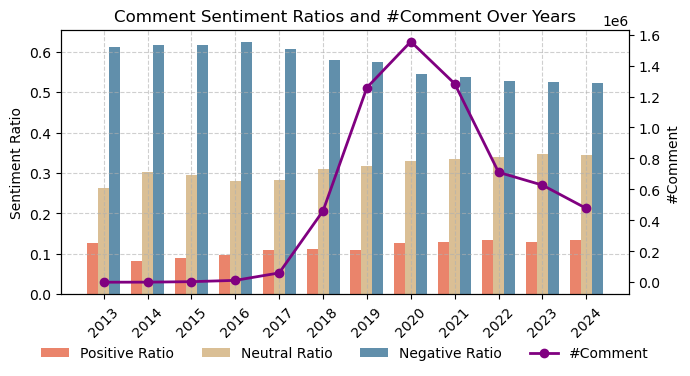

In [232]:
draw_bar_line(comment_sentiment_counts, 'Comment')

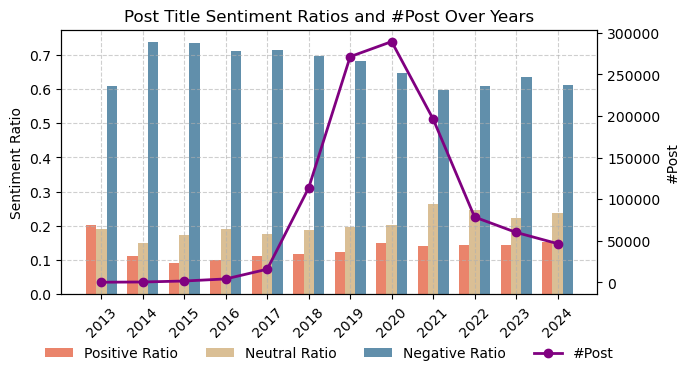

In [233]:
draw_bar_line(post_title_sentiment_counts, 'Post Title')

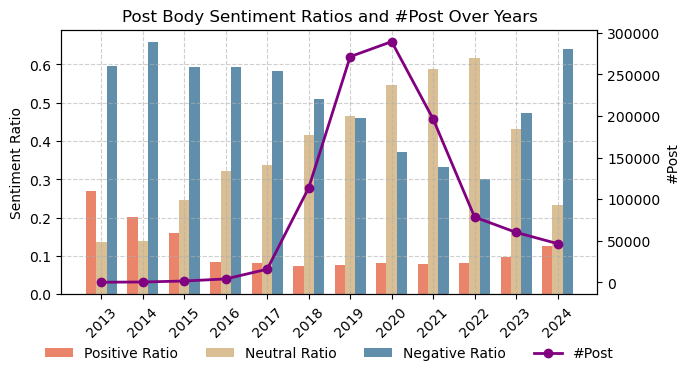

In [234]:
draw_bar_line(post_body_sentiment_counts, 'Post Body')